# Strategy Comparison Analysis
This notebook compares the simulation results of three different placement strategies:
1. **Latency-aware**
2. **Custom (Proposed by Felipe)**
3. **Round Robin**

We will analyze Latency, Service Time, Network Wait Time, and Load Balancing.

In [63]:
# 1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

In [64]:
# 2. Load and Combine Datasets

# Define file paths and labels
files = {
    'Latency': 'resultados/5-latency-sim_trace.csv',
    'Custom': 'resultados/5-custom_proposed_by_felipe-sim_trace.csv',
    'Round Robin': 'resultados/5-roundRobin-sim_trace.csv'
}

dfs = []

for algo, path in files.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        temp_df['Algorithm'] = algo
        dfs.append(temp_df)
        print(f"Loaded {algo}: {len(temp_df)} records")
    else:
        print(f"File not found: {path}")

# Concatenate all dataframes
if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    display(df_all.head())
    print(f"Total records: {len(df_all)}")
else:
    print("No data loaded.")

Loaded Latency: 25212 records
Loaded Custom: 23006 records
Loaded Round Robin: 20207 records


,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception,Algorithm
0,-1,COMP_M,Application-1222,Application-1222-Service,M_Req,4007,4006,2511,4,Application-1222-Sensor,Fog-3,Application-1222-Sensor,0.034207,110.770568,110.804775,0.0,110.770568,Latency
1,-1,COMP_M,Application-538,Application-538-Service,M_Req,2639,2638,1143,3,Application-538-Sensor,Fog-2,Application-538-Sensor,0.041478,111.286986,111.328464,0.0,111.286986,Latency
2,-1,COMP_M,Application-941,Application-941-Service,M_Req,3445,3444,1949,1,Application-941-Sensor,Fog-0,Application-941-Sensor,0.031924,111.295194,111.327117,0.0,111.295194,Latency
3,-1,COMP_M,Application-1107,Application-1107-Service,M_Req,3777,3776,2281,4,Application-1107-Sensor,Fog-3,Application-1107-Sensor,0.021768,111.312816,111.334584,0.0,111.312816,Latency
4,-1,COMP_M,Application-245,Application-245-Service,M_Req,2053,2052,557,2,Application-245-Sensor,Fog-1,Application-245-Sensor,0.037753,111.399119,111.436872,0.0,111.399119,Latency


Total records: 68425


In [65]:
# 3. Data Preprocessing & Metric Calculation

# Calculate Latency (ms)
df_all['Latency'] = df_all['service'] * 1000

# Calculate Service Time (ms)
df_all['Service_Time'] = (df_all['time_out'] - df_all['time_in']) * 1000

# Calculate Network/Wait Time (ms)
df_all['Network_Wait_Time'] = df_all['Latency'] - df_all['Service_Time']

# Display summary statistics by Algorithm
display(df_all.groupby('Algorithm')[['Latency', 'Service_Time', 'Network_Wait_Time']].describe())

Latency                                                        \
               count       mean        std       min        25%        50%   
Algorithm                                                                    
Custom       23006.0  24.932100  11.557308  8.348208  15.113487  21.470006   
Latency      25212.0  25.032687  11.687208  8.354992  15.106271  21.581442   
Round Robin  20207.0  25.115431  11.734211  8.369617  15.100624  21.569346   

                                  Service_Time             ...             \
                   75%        max        count       mean  ...        75%   
Algorithm                                                  ...              
Custom       34.458563  49.554097      23006.0  24.932100  ...  34.458563   
Latency      34.740274  51.647583      25212.0  25.032687  ...  34.740274   
Round Robin  34.822366  51.583530      20207.0  25.115431  ...  34.822366   

                       Network_Wait_Time                              \
                   max             count          mean           std   
Algorithm                                                              
Custom       49.554097           23006.0  8.283609e-14  4.637458e-11   
Latency      51.647583           25212.0 -1.977701e-14  4.659398e-11   
Round Robin  51.583530           20207.0 -3.652551e-14  4.644865e-11   

                                                                     \
                      min           25%           50%           75%   
Algorithm                                                             
Custom      -2.840963e-10 -2.116041e-11 -7.105427e-14  2.129319e-11   
Latency     -2.839258e-10 -2.111866e-11 -5.151435e-14  2.130562e-11   
Round Robin -2.824017e-10 -2.097877e-11 -7.815970e-14  2.121503e-11   

                           
                      max  
Algorithm                  
Custom       2.802718e-10  
Latency      2.834639e-10  
Round Robin  2.840679e-10  

[3 rows x 24 columns]

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_22130/563496200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Algorithm', y='Latency', data=df_all, palette="Set2")


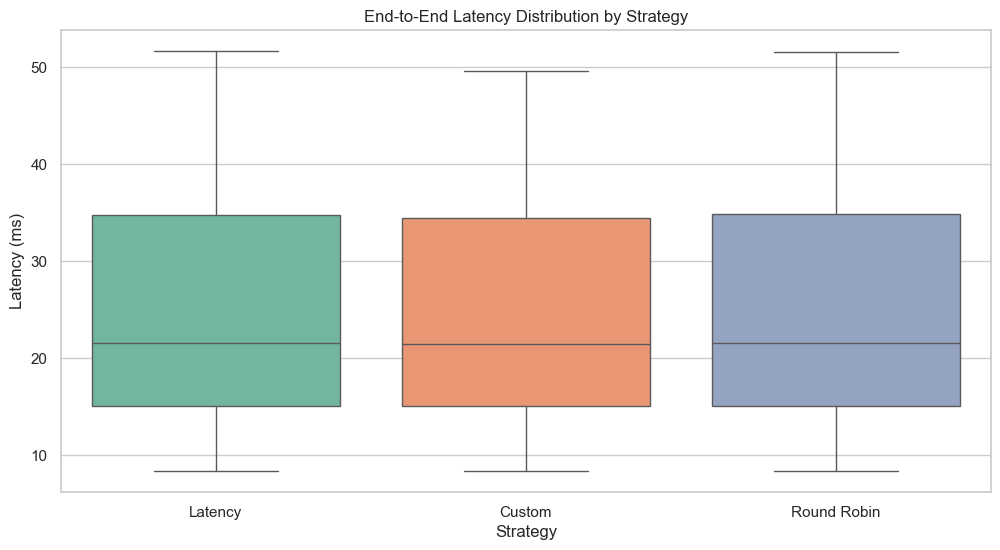

In [66]:
# 4. Comparative Analysis: End-to-End Latency

plt.figure(figsize=(12, 6))
sns.boxplot(x='Algorithm', y='Latency', data=df_all, palette="Set2")
plt.title('End-to-End Latency Distribution by Strategy')
plt.ylabel('Latency (ms)')
plt.xlabel('Strategy')
plt.show()

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_22130/104097126.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Algorithm', y='Latency', data=avg_latency, palette="viridis")


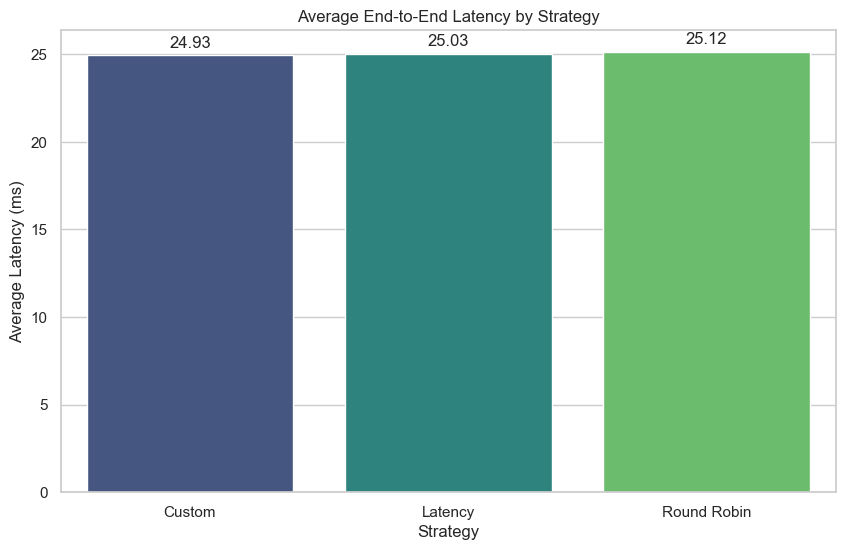

In [67]:
# Average Latency Comparison (Bar Chart)
plt.figure(figsize=(10, 6))
# Calculate means for plotting
avg_latency = df_all.groupby('Algorithm')['Latency'].mean().reset_index()
ax = sns.barplot(x='Algorithm', y='Latency', data=avg_latency, palette="viridis")

plt.title('Average End-to-End Latency by Strategy')
plt.ylabel('Average Latency (ms)')
plt.xlabel('Strategy')

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.show()

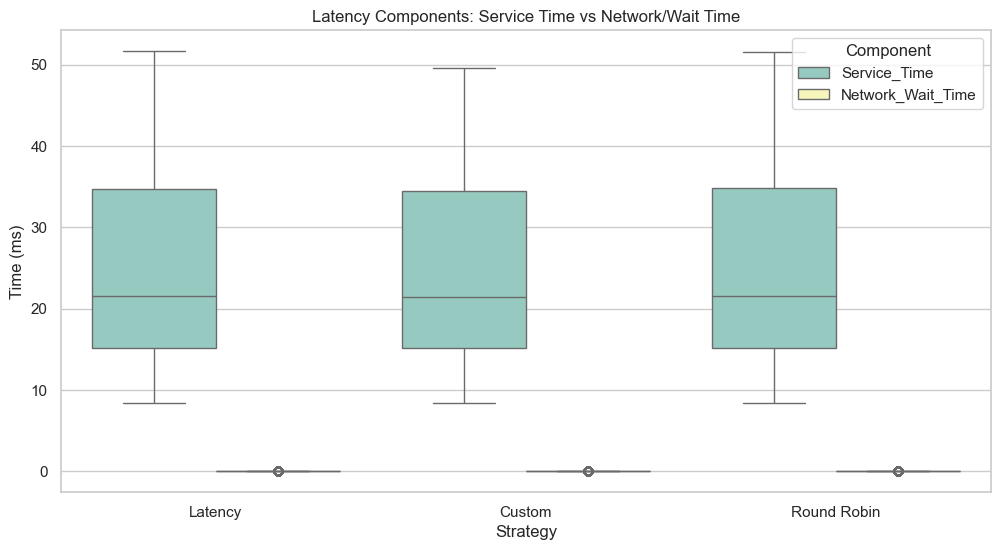

In [68]:
# 5. Component Analysis: Service vs. Network Time

# Melt the dataframe to have a long format for plotting
df_melted = df_all.melt(id_vars=['Algorithm'], value_vars=['Service_Time', 'Network_Wait_Time'], 
                        var_name='Component', value_name='Time_ms')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Algorithm', y='Time_ms', hue='Component', data=df_melted, palette="Set3")
plt.title('Latency Components: Service Time vs Network/Wait Time')
plt.ylabel('Time (ms)')
plt.xlabel('Strategy')
plt.legend(title='Component')
plt.show()

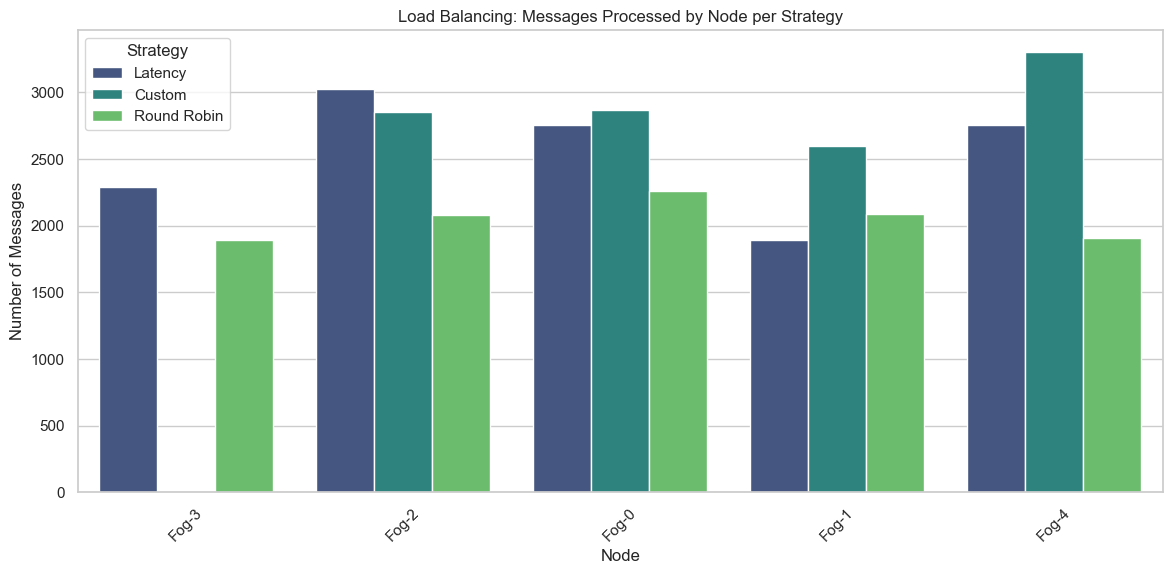

In [69]:
# 6. Load Balancing Analysis

# Filter for M_Req messages (requests processed by Fog/Cloud nodes)
df_req = df_all[df_all['message'] == 'M_Req']

plt.figure(figsize=(14, 6))
sns.countplot(x='TOPO.dstLabel', hue='Algorithm', data=df_req, palette="viridis")
plt.title('Load Balancing: Messages Processed by Node per Strategy')
plt.xlabel('Node')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.legend(title='Strategy')
plt.show()

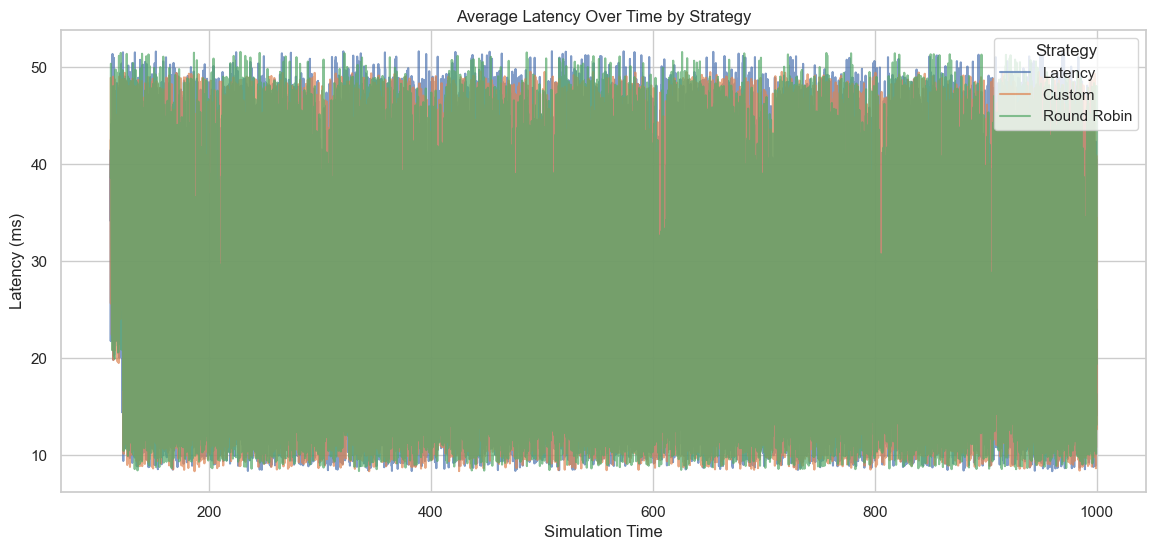

In [70]:
# 7. Latency Trends Over Time

plt.figure(figsize=(14, 6))
sns.lineplot(x='time_reception', y='Latency', hue='Algorithm', data=df_all, alpha=0.7)
plt.title('Average Latency Over Time by Strategy')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend(title='Strategy')
plt.show()

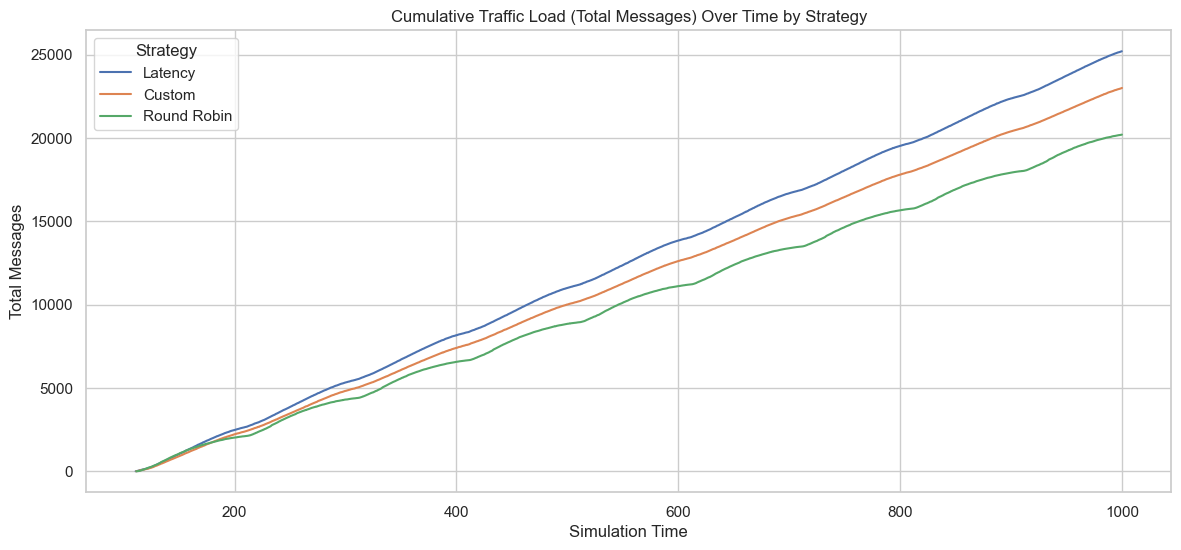

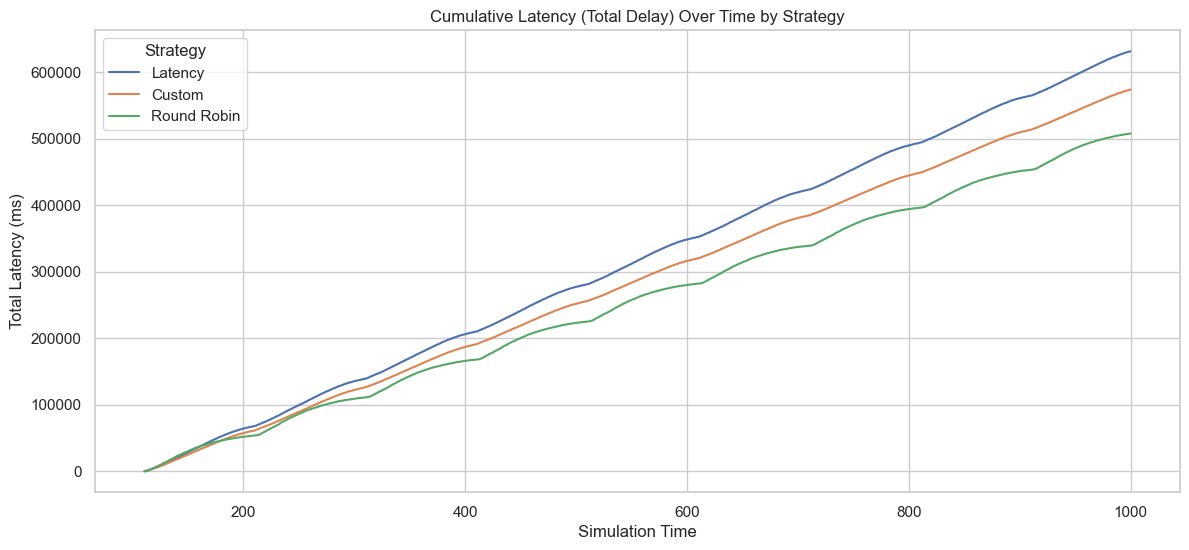

In [71]:
# Cumulative Analysis: Traffic and Latency

# Sort by time_reception to ensure correct cumulative calculation
df_all = df_all.sort_values('time_reception')

# Calculate cumulative metrics per Algorithm
df_all['cumulative_messages'] = df_all.groupby('Algorithm').cumcount() + 1
df_all['cumulative_latency'] = df_all.groupby('Algorithm')['Latency'].cumsum()

# Plot 1: Cumulative Messages
plt.figure(figsize=(14, 6))
sns.lineplot(x='time_reception', y='cumulative_messages', hue='Algorithm', data=df_all)
plt.title('Cumulative Traffic Load (Total Messages) Over Time by Strategy')
plt.xlabel('Simulation Time')
plt.ylabel('Total Messages')
plt.legend(title='Strategy')
plt.show()

# Plot 2: Cumulative Latency
plt.figure(figsize=(14, 6))
sns.lineplot(x='time_reception', y='cumulative_latency', hue='Algorithm', data=df_all)
plt.title('Cumulative Latency (Total Delay) Over Time by Strategy')
plt.xlabel('Simulation Time')
plt.ylabel('Total Latency (ms)')
plt.legend(title='Strategy')
plt.show()

In [72]:
# Investigation: Why is Cumulative Latency lower?
# Cumulative Latency = Sum(Latency of all messages)
# It depends on two factors:
# 1. The Average Latency per message.
# 2. The Total Number of messages processed.

# Let's look at both:
summary = df_all.groupby('Algorithm').agg(
    Average_Latency=('Latency', 'mean'),
    Total_Messages=('Latency', 'count'),
    Total_Cumulative_Latency=('Latency', 'sum')
).sort_values('Total_Cumulative_Latency')

display(summary)

print("\nObservation:")
print("If 'Total_Messages' varies significantly, a strategy with fewer processed messages")
print("might show a lower Cumulative Latency simply because it has summed fewer values,")
print("even if its Average Latency is higher.")

,Average_Latency,Total_Messages,Total_Cumulative_Latency
Algorithm,,,
Round Robin,25.115431,20207,507507.510796
Custom,24.932100,23006,573587.892430
Latency,25.032687,25212,631124.112010



Observation:
If 'Total_Messages' varies significantly, a strategy with fewer processed messages
might show a lower Cumulative Latency simply because it has summed fewer values,
even if its Average Latency is higher.


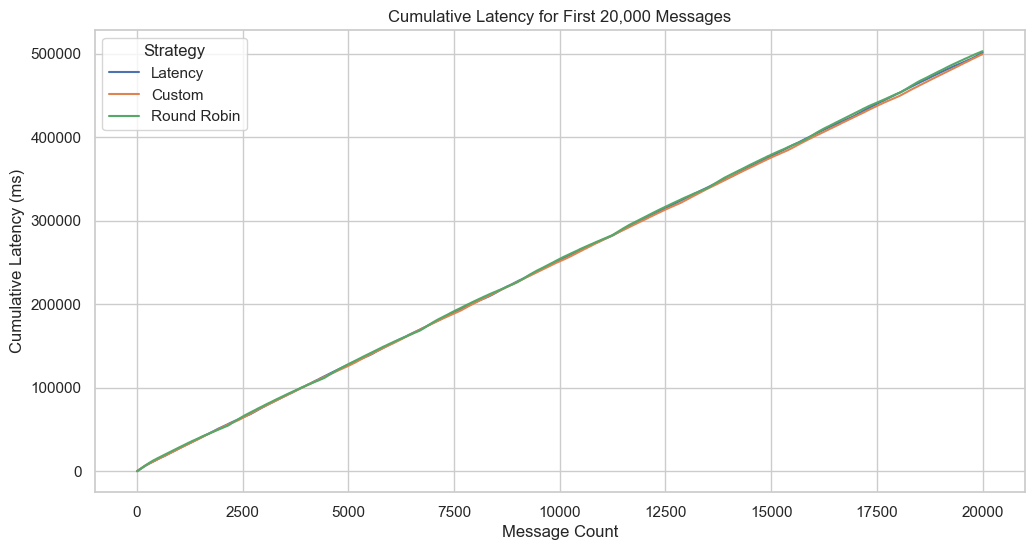

,count,mean,sum
Algorithm,,,
Custom,20000,24.975448,499508.962827
Latency,20000,25.064174,501283.470472
Round Robin,20000,25.153643,503072.859179


In [73]:
# Normalized Cumulative Latency (First 20,000 Messages)

# Filter for the first 20,000 messages per algorithm
df_normalized = df_all.groupby('Algorithm').head(20000).copy()

# Recalculate cumulative latency for this subset
df_normalized['cumulative_latency'] = df_normalized.groupby('Algorithm')['Latency'].cumsum()
df_normalized['message_count'] = df_normalized.groupby('Algorithm').cumcount() + 1

plt.figure(figsize=(12, 6))
sns.lineplot(x='message_count', y='cumulative_latency', hue='Algorithm', data=df_normalized)
plt.title('Cumulative Latency for First 20,000 Messages')
plt.xlabel('Message Count')
plt.ylabel('Cumulative Latency (ms)')
plt.legend(title='Strategy')
plt.show()

# Display summary for this normalized subset
display(df_normalized.groupby('Algorithm')['Latency'].agg(['count', 'mean', 'sum']))

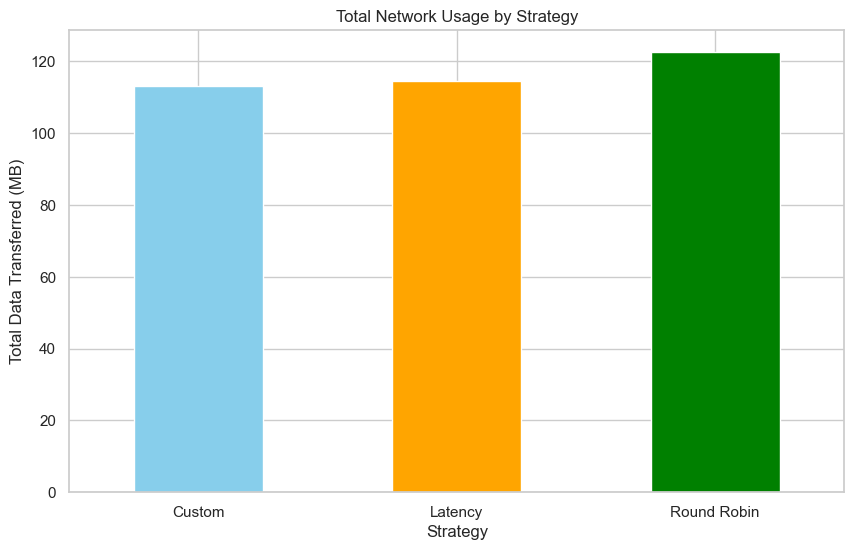

,Total Data (MB)
Algorithm,
Custom,113.066126
Latency,114.660346
Round Robin,122.580858


In [74]:
# 8. Network Usage Analysis (Bonus)

link_files = {
    'Latency': 'resultados/5-latency-sim_trace_link.csv',
    'Custom': 'resultados/5-custom_proposed_by_felipe-sim_trace_link.csv',
    'Round Robin': 'resultados/5-roundRobin-sim_trace_link.csv'
}

link_dfs = []
for algo, path in link_files.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        temp_df['Algorithm'] = algo
        link_dfs.append(temp_df)

if link_dfs:
    df_link_all = pd.concat(link_dfs, ignore_index=True)
    
    # Calculate Total Data Transferred (MB)
    # Assuming 'size' is in bytes (or bits? usually bytes in YAFS if not specified, but let's assume bytes based on previous context)
    # If 'size' is bits, divide by 8 * 1024 * 1024. If bytes, divide by 1024 * 1024.
    # Let's assume Bytes as per standard.
    
    network_usage = df_link_all.groupby('Algorithm')['size'].sum() / (1024 * 1024) # MB
    
    plt.figure(figsize=(10, 6))
    network_usage.plot(kind='bar', color=['skyblue', 'orange', 'green'])
    plt.title('Total Network Usage by Strategy')
    plt.ylabel('Total Data Transferred (MB)')
    plt.xlabel('Strategy')
    plt.xticks(rotation=0)
    plt.show()
    
    display(network_usage.to_frame(name='Total Data (MB)'))